# Window-Level Anomaly Prediction from BGL Logs

This notebook uses **BGL Part 1 feature extraction output directly** to build a window-level anomaly classification pipeline.

1. Load exported BGL features from Part 1 (`artifacts/bgl_log_feature_extraction/bgl_log_features.csv`)
2. Validate and repair BGL schema fields if needed
3. Aggregate events into fixed 5-minute windows
4. Define abnormalities by percentile threshold on service anomaly score
5. Predict whether the **next** window is abnormal
6. Compare 4 model families: Logistic Regression, SVC, Random Forest, Gaussian Naive Bayes

Goal: reach at least 85% classification accuracy while comparing precision/recall/F1 trade-offs.

In [56]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

In [57]:
project_root = Path('..').resolve()
candidate_feature_files = [
    project_root / 'artifacts' / 'bgl_log_feature_extraction' / 'bgl_log_features.csv',
    project_root / 'artifacts' / 'hpc_log_feature_extraction' / 'hpc_log_features.csv',
]

def is_lfs_pointer_csv(path: Path) -> bool:
    if not path.exists():
        return False
    first_line = path.open('r', errors='ignore').readline().strip()
    return first_line.startswith('version https://git-lfs.github.com/spec/v1')

selected_path = None
for candidate in candidate_feature_files:
    if candidate.exists() and not is_lfs_pointer_csv(candidate):
        selected_path = candidate
        break

if selected_path is None:
    raise FileNotFoundError(
        'No usable BGL/HPC feature output found. Ensure Notebook 04 export is generated and LFS files are pulled.'
    )

available_cols = pd.read_csv(selected_path, nrows=0).columns.tolist()
required_cols = ['timestamp', 'location', 'message', 'is_anomaly']
optional_cols = ['level', 'facility', 'component', 'template_id', 'template_frequency', 'message_length', 'message_token_count']

missing_required = [c for c in required_cols if c not in available_cols]
if missing_required:
    raise ValueError(
        'Feature file is missing required columns: ' + ', '.join(missing_required)
    )

usecols = [c for c in required_cols + optional_cols if c in available_cols]
df_features = pd.read_csv(selected_path, usecols=usecols)

# Standardize field names expected by downstream pipeline
df_features = df_features.rename(columns={'timestamp': 'datetime', 'location': 'host', 'message': 'endpoint'})
df_features['datetime'] = pd.to_datetime(df_features['datetime'], errors='coerce')
df_features['endpoint'] = df_features['endpoint'].fillna('')
df_features['host'] = df_features['host'].fillna('')

if 'message_length' not in df_features.columns:
    df_features['message_length'] = df_features['endpoint'].str.len().fillna(0)
if 'message_token_count' not in df_features.columns:
    df_features['message_token_count'] = df_features['endpoint'].str.split().str.len().fillna(0)
if 'template_id' not in df_features.columns:
    df_features['template_id'] = pd.factorize(df_features['endpoint'])[0]

df_features['bytes_filled'] = pd.to_numeric(df_features['message_length'], errors='coerce').fillna(0)
df_features['is_error'] = pd.to_numeric(df_features['is_anomaly'], errors='coerce').fillna(0).astype(int)

if 'level' not in df_features.columns:
    df_features['level'] = 'INFO'
level_upper = df_features['level'].astype(str).str.upper()
df_features['count_4xx_seed'] = level_upper.isin(['WARNING']).astype(int)
df_features['count_5xx_seed'] = level_upper.isin(['ERROR', 'SEVERE', 'FATAL', 'FAILURE']).astype(int)

before_drop = len(df_features)
df_features = df_features.dropna(subset=['datetime']).copy()
after_drop = len(df_features)

print('Loaded feature file from:', selected_path)
print('Rows loaded:', before_drop, '| Rows with valid datetime:', after_drop)
df_features.head()

Loaded feature file from: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction/bgl_log_features.csv
Rows loaded: 297834 | Rows with valid datetime: 297834


,is_anomaly,datetime,host,facility,component,level,endpoint,message_length,message_token_count,template_id,template_frequency,bytes_filled,is_error,count_4xx_seed,count_5xx_seed
0,0,2005-06-25 03:34:02.918500,R30-M0-N7-C:J11-U01,RAS,KERNEL,INFO,257923536 double-hummer alignment exceptions,44,4,0,18582,44,0,0,0
1,0,2005-07-09 10:13:26.900784,R12-M1-N6-C:J13-U01,RAS,KERNEL,INFO,generating core.8437,20,2,1,107669,20,0,0,0
2,0,2005-09-20 12:09:25.304629,,RAS,MMCS,ERROR,idoproxydb hit ASSERT condition: ASSERT expres...,171,13,2,5317,171,0,0,1
3,0,2005-11-26 05:28:49.225106,R22-M0-N4-I:J18-U01,RAS,KERNEL,INFO,"ciod: Received signal 15, code=0, errno=0, add...",61,7,3,2543,61,0,0,0
4,0,2005-06-30 15:59:49.329370,R03-M0-NB-C:J10-U11,RAS,KERNEL,INFO,41 ddr errors(s) detected and corrected on ran...,67,13,4,2114,67,0,0,0


In [60]:
required_for_windowing = [
    'datetime', 'host', 'endpoint',
    'bytes_filled', 'is_error', 'count_4xx_seed', 'count_5xx_seed', 'template_id'
 ]
missing_for_windowing = [c for c in required_for_windowing if c not in df_features.columns]
if missing_for_windowing:
    raise ValueError(
        'Feature output is still missing required fields for Part 2: ' + ', '.join(missing_for_windowing)
    )

print('Part 2 is using extracted BGL features directly.')
print('Columns available for modeling pipeline:', sorted(df_features.columns.tolist()))
print('Event-level anomaly rate in input data:', round(df_features['is_error'].mean(), 5))

df_features[['datetime', 'host', 'endpoint', 'bytes_filled', 'is_error', 'count_4xx_seed', 'count_5xx_seed']].head()

Part 2 is using extracted BGL features directly.
Columns available for modeling pipeline: ['bytes_filled', 'component', 'count_4xx_seed', 'count_5xx_seed', 'datetime', 'endpoint', 'facility', 'host', 'is_anomaly', 'is_error', 'level', 'message_length', 'message_token_count', 'template_frequency', 'template_id']
Event-level anomaly rate in input data: 0.07395


,datetime,host,endpoint,bytes_filled,is_error,count_4xx_seed,count_5xx_seed
0,2005-06-25 03:34:02.918500,R30-M0-N7-C:J11-U01,257923536 double-hummer alignment exceptions,44,0,0,0
1,2005-07-09 10:13:26.900784,R12-M1-N6-C:J13-U01,generating core.8437,20,0,0,0
2,2005-09-20 12:09:25.304629,,idoproxydb hit ASSERT condition: ASSERT expres...,171,0,0,1
3,2005-11-26 05:28:49.225106,R22-M0-N4-I:J18-U01,"ciod: Received signal 15, code=0, errno=0, add...",61,0,0,0
4,2005-06-30 15:59:49.329370,R03-M0-NB-C:J10-U11,41 ddr errors(s) detected and corrected on ran...,67,0,0,0


## Manual Features in 5-Minute Windows
We aggregate BGL events into fixed 5-minute frames and compute manual service-behavior features used for classification.

In [61]:
window_features = (
    df_features
    .set_index('datetime')
    .sort_index()
    .resample('5min')
    .agg(
        request_count=('endpoint', 'size'),
        unique_ips=('host', 'nunique'),
        error_count=('is_error', 'sum'),
        avg_response_size=('bytes_filled', 'mean'),
        p95_response_size=('bytes_filled', lambda x: x.quantile(0.95)),
        unique_endpoints=('template_id', 'nunique'),
        count_4xx=('count_4xx_seed', 'sum'),
        count_5xx=('count_5xx_seed', 'sum'),
    )
    .reset_index()
)

window_features[['avg_response_size', 'p95_response_size']] = window_features[['avg_response_size', 'p95_response_size']].fillna(0)
window_features['error_rate'] = np.where(
    window_features['request_count'] > 0,
    window_features['error_count'] / window_features['request_count'],
    0
)
window_features['rate_4xx'] = np.where(
    window_features['request_count'] > 0,
    window_features['count_4xx'] / window_features['request_count'],
    0
)
window_features['rate_5xx'] = np.where(
    window_features['request_count'] > 0,
    window_features['count_5xx'] / window_features['request_count'],
    0
)

window_features.head()

,datetime,request_count,unique_ips,error_count,avg_response_size,p95_response_size,unique_endpoints,count_4xx,count_5xx,error_rate,rate_4xx,rate_5xx
0,2005-06-03 15:40:00,40,1,0,40.000000,40.0,1,0,0,0.0,0.0,0.0
1,2005-06-03 15:45:00,88,1,0,40.000000,40.0,1,0,0,0.0,0.0,0.0
2,2005-06-03 15:50:00,82,2,0,39.756098,40.0,2,0,0,0.0,0.0,0.0
3,2005-06-03 15:55:00,53,1,0,40.000000,40.0,1,0,0,0.0,0.0,0.0
4,2005-06-03 16:00:00,30,2,0,39.300000,40.0,2,0,0,0.0,0.0,0.0


In [62]:
traffic_cols = ['request_count', 'unique_ips', 'unique_endpoints', 'p95_response_size']
for col in traffic_cols:
    col_std = window_features[col].std(ddof=0)
    if col_std == 0 or np.isnan(col_std):
        window_features[f'z_{col}'] = 0.0
    else:
        window_features[f'z_{col}'] = (window_features[col] - window_features[col].mean()) / col_std

window_features['traffic_anomaly_score'] = (
    0.35 * window_features['z_request_count'] +
    0.25 * window_features['z_unique_ips'] +
    0.20 * window_features['z_unique_endpoints'] +
    0.20 * window_features['z_p95_response_size']
)

window_features[['datetime', 'traffic_anomaly_score'] + [f'z_{c}' for c in traffic_cols]].head()

,datetime,traffic_anomaly_score,z_request_count,z_unique_ips,z_unique_endpoints,z_p95_response_size
0,2005-06-03 15:40:00,0.420826,0.692632,-0.066543,0.104531,0.870673
1,2005-06-03 15:45:00,0.751563,1.637596,-0.066543,0.104531,0.870673
2,2005-06-03 15:50:00,0.750554,1.519476,-0.044982,0.279243,0.870673
3,2005-06-03 15:55:00,0.510401,0.948560,-0.066543,0.104531,0.870673
4,2005-06-03 16:00:00,0.392255,0.495764,-0.044982,0.279243,0.870673


## Service Behavior Anomaly Features
This block creates service-specific anomaly signals from 5-minute BGL windows.

It captures abnormal surges in event volume, unique location churn, message-template diversity shifts, and severe-level spikes.

In [63]:
threshold_q = 0.95

# Use only windows with traffic for anomaly definition and supervised learning
active_windows = window_features.loc[window_features['request_count'] > 0].copy()

service_signal_cols = ['rate_5xx', 'rate_4xx', 'traffic_anomaly_score', 'error_rate']
for col in service_signal_cols:
    col_std = active_windows[col].std(ddof=0)
    if col_std == 0 or np.isnan(col_std):
        active_windows[f'z_{col}'] = 0.0
    else:
        active_windows[f'z_{col}'] = (active_windows[col] - active_windows[col].mean()) / col_std

# Composite service behavior anomaly score
active_windows['service_anomaly_score'] = (
    0.40 * active_windows['z_rate_5xx'] +
    0.25 * active_windows['z_rate_4xx'] +
    0.20 * active_windows['z_traffic_anomaly_score'] +
    0.15 * active_windows['z_error_rate']
)

service_threshold = active_windows['service_anomaly_score'].quantile(threshold_q)
active_windows['is_abnormal'] = (active_windows['service_anomaly_score'] >= service_threshold).astype(int)
threshold_basis = 'service_anomaly_score'
error_threshold = service_threshold

active_windows['target_next_window_abnormal'] = active_windows['is_abnormal'].shift(-1)

supervised_df = active_windows.dropna(subset=['target_next_window_abnormal']).copy()
supervised_df['target_next_window_abnormal'] = supervised_df['target_next_window_abnormal'].astype(int)

class_balance = supervised_df['target_next_window_abnormal'].value_counts().to_dict()
if len(class_balance) < 2:
    raise ValueError(
        'Target contains only one class after labeling. Re-run Part 1 export with more rows or adjust threshold_q.'
    )

print('Total 5-min windows:', len(window_features))
print('Active windows used:', len(active_windows))
print('Supervised rows:', len(supervised_df))
print(f'Anomaly threshold basis: {threshold_basis}, q={threshold_q}, value={round(float(error_threshold), 5)}')
print('Target class balance:', class_balance)
print('Positive rate of next-window abnormal:', round(supervised_df['target_next_window_abnormal'].mean(), 4))

supervised_df[[
    'datetime', 'request_count', 'rate_4xx', 'rate_5xx',
    'traffic_anomaly_score', 'service_anomaly_score',
    'is_abnormal', 'target_next_window_abnormal'
]].head()

Total 5-min windows: 61825
Active windows used: 6723
Supervised rows: 6722
Anomaly threshold basis: service_anomaly_score, q=0.95, value=1.41618
Target class balance: {0: 6380, 1: 342}
Positive rate of next-window abnormal: 0.0509


,datetime,request_count,rate_4xx,rate_5xx,traffic_anomaly_score,service_anomaly_score,is_abnormal,target_next_window_abnormal
0,2005-06-03 15:40:00,40,0.0,0.0,0.420826,-0.354990,0,0
1,2005-06-03 15:45:00,88,0.0,0.0,0.751563,-0.321367,0,0
2,2005-06-03 15:50:00,82,0.0,0.0,0.750554,-0.321470,0,0
3,2005-06-03 15:55:00,53,0.0,0.0,0.510401,-0.345884,0,0
4,2005-06-03 16:00:00,30,0.0,0.0,0.392255,-0.357895,0,0


## Methods and Comparison (Assignment Mapping)
We solve a window-level service behavior anomaly classification problem and compare **4 distinct methods** from different option groups:

1. **(a) Logistic Regression** (Generalized Linear Model family)
2. **(c) Support Vector Classifier** (robust inference method)
3. **(f) Random Forest** (ensemble learning)
4. **(h) Gaussian Naive Bayes** (another inference method from class list)

Primary comparison metrics: accuracy, precision, recall, and F1.
Assignment target check: at least one classifier should achieve accuracy > 85%.

In [64]:
feature_cols = [
    'request_count',
    'unique_ips',
    'error_count',
    'error_rate',
    'avg_response_size',
    'p95_response_size',
    'unique_endpoints',
    'count_4xx',
    'count_5xx',
    'rate_4xx',
    'rate_5xx',
    'traffic_anomaly_score',
    'service_anomaly_score',
]

X = supervised_df[feature_cols].copy()
y = supervised_df['target_next_window_abnormal'].copy()

split_idx = int(len(supervised_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train rows:', len(X_train), '| Test rows:', len(X_test))
print('Train positive rate:', round(y_train.mean(), 4), '| Test positive rate:', round(y_test.mean(), 4))

Train rows: 5377 | Test rows: 1345
Train positive rate: 0.0537 | Test positive rate: 0.0394


In [65]:
models = {
    'Logistic Regression': {
        'option': '(a)',
        'model': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
        ),
    },
    'Support Vector Classifier': {
        'option': '(c)',
        'model': make_pipeline(
            StandardScaler(),
            SVC(kernel='rbf', class_weight='balanced', random_state=42)
        ),
    },
    'Random Forest': {
        'option': '(f)',
        'model': RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced_subsample',
            n_jobs=-1
        ),
    },
    'Gaussian Naive Bayes': {
        'option': '(h)',
        'model': make_pipeline(
            StandardScaler(),
            GaussianNB()
        ),
    },
}

results = []
predictions = {}

for model_name, info in models.items():
    model = info['model']
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    results.append({
        'method_option': info['option'],
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(['accuracy', 'f1'], ascending=False)
    .reset_index(drop=True)
)

meets_assignment = bool((results_df['accuracy'] > 0.85).any())
print('Assignment target met (at least one model accuracy > 85%):', meets_assignment)

results_df

Assignment target met (at least one model accuracy > 85%): True


,method_option,model,accuracy,precision,recall,f1
0,(f),Random Forest,0.919703,0.076923,0.094340,0.084746
1,(h),Gaussian Naive Bayes,0.915985,0.200000,0.377358,0.261438
2,(c),Support Vector Classifier,0.866914,0.137931,0.452830,0.211454
3,(a),Logistic Regression,0.864684,0.089172,0.264151,0.133333


Best model: Random Forest
Best accuracy: 0.9197
Target met (>= 0.85 accuracy): True


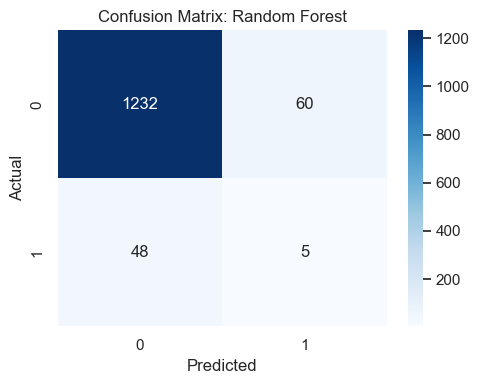

In [66]:
best_model_name = results_df.iloc[0]['model']
best_pred = predictions[best_model_name]
best_accuracy = results_df.iloc[0]['accuracy']

print('Best model:', best_model_name)
print('Best accuracy:', round(best_accuracy, 4))
print('Target met (>= 0.85 accuracy):', bool(best_accuracy >= 0.85))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Comparison rows: 1345
Mismatches: 108


,datetime,ground_truth,inference,match,error_type
0,2005-11-17 05:30:00,0,0,True,correct
1,2005-11-17 05:35:00,0,0,True,correct
2,2005-11-17 05:40:00,1,0,False,false_negative
3,2005-11-17 05:50:00,0,1,False,false_positive
4,2005-11-17 05:55:00,0,0,True,correct
5,2005-11-17 06:10:00,0,0,True,correct
6,2005-11-17 06:15:00,0,0,True,correct
7,2005-11-17 06:20:00,0,0,True,correct
8,2005-11-17 06:45:00,0,0,True,correct
9,2005-11-17 08:00:00,0,0,True,correct


,error_type,count
0,correct,1237
1,false_positive,60
2,false_negative,48


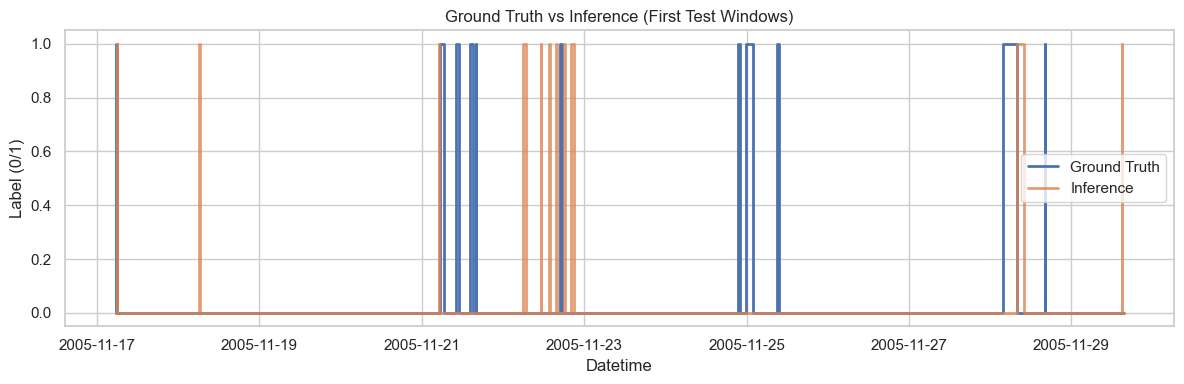

In [67]:
test_windows = supervised_df.iloc[split_idx:].copy().reset_index(drop=True)
comparison_df = pd.DataFrame({
    'datetime': test_windows['datetime'].values,
    'ground_truth': y_test.to_numpy(),
    'inference': best_pred,
})
comparison_df['match'] = (comparison_df['ground_truth'] == comparison_df['inference'])
comparison_df['error_type'] = np.where(
    comparison_df['match'],
    'correct',
    np.where(comparison_df['ground_truth'] == 1, 'false_negative', 'false_positive')
)

print('Comparison rows:', len(comparison_df))
print('Mismatches:', int((~comparison_df['match']).sum()))
display(comparison_df.head(20))

display(comparison_df['error_type'].value_counts().rename_axis('error_type').reset_index(name='count'))

plot_n = min(300, len(comparison_df))
plot_df = comparison_df.iloc[:plot_n].copy()

plt.figure(figsize=(12, 4))
plt.step(plot_df['datetime'], plot_df['ground_truth'], where='post', label='Ground Truth', linewidth=2)
plt.step(plot_df['datetime'], plot_df['inference'], where='post', label='Inference', linewidth=2, alpha=0.8)
plt.title('Ground Truth vs Inference (First Test Windows)')
plt.xlabel('Datetime')
plt.ylabel('Label (0/1)')
plt.legend()
plt.tight_layout()
plt.show()

## Inference vs Ground Truth (Side-by-Side)
This section compares predicted labels against ground-truth labels for the test windows.
It helps inspect where the model misses anomalies (false negatives) or raises false alarms (false positives).

In [68]:
artifacts_dir = project_root / 'artifacts' / 'window_level_models'
artifacts_dir.mkdir(parents=True, exist_ok=True)

window_features_path = artifacts_dir / 'window_features_5min.csv'
results_path = artifacts_dir / 'model_comparison_metrics.csv'
multi_results_path = artifacts_dir / 'model_comparison_metrics_multiclass.csv'

window_features.to_csv(window_features_path, index=False)
results_df.to_csv(results_path, index=False)
if 'multi_results_df' in globals():
    multi_results_df.to_csv(multi_results_path, index=False)

print('Saved window-level features to:', window_features_path)
print('Saved model metrics to:', results_path)
if 'multi_results_df' in globals():
    print('Saved multiclass model metrics to:', multi_results_path)

Saved window-level features to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/window_features_5min.csv
Saved model metrics to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/model_comparison_metrics.csv
Saved multiclass model metrics to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/model_comparison_metrics_multiclass.csv


## Multi-Level Severity Inference (Quantile-Based, Unique Method Families)
This section performs **quantile-based severity inference** with one method from each family (used once):

- **(a)** Generalized Linear Model: Logistic Regression
- **(c)** Robust inference method: Support Vector Classifier
- **(d)** Neural network: MLP Classifier
- **(f)** Ensemble learning: Random Forest

Target is quantile-severity class of the current window (D1 to D10), built from normalized service anomaly score.

In [69]:
# Build quantile-based multiclass inference target from current-window severity
supervised_df = supervised_df.copy().sort_values('datetime').reset_index(drop=True)

multi_df = supervised_df.copy()

score_min = float(multi_df['service_anomaly_score'].min())
score_max = float(multi_df['service_anomaly_score'].max())
score_span = score_max - score_min
if score_span <= 0:
    raise ValueError('Cannot create quantile classes because service anomaly score has no variation.')

multi_df['service_score_norm'] = (multi_df['service_anomaly_score'] - score_min) / score_span
multi_df['service_score_norm'] = multi_df['service_score_norm'].clip(0.0, 1.0)

# Quantile-based 10 classes (D1..D10)
multi_df['severity_class'] = pd.qcut(
    multi_df['service_score_norm'],
    q=10,
    labels=False,
    duplicates='drop',
).astype(int)

multi_df['curr_severity_class'] = multi_df['severity_class'].astype(int)
multi_df['prev_severity_class'] = multi_df['curr_severity_class'].shift(1)

available_class_ids = sorted(multi_df['severity_class'].unique().tolist())
if len(available_class_ids) < 10:
    print(f'Warning: only {len(available_class_ids)} classes due to duplicate quantile edges.')

class_ranges = (
    multi_df.groupby('severity_class')['service_score_norm']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('severity_class')
)
id_to_label = {
    int(row.severity_class): f"D{int(row.severity_class)+1} [{row.min:.3f}-{row.max:.3f}]"
    for row in class_ranges.itertuples(index=False)
}

# Temporal features from Part 1-derived signals
temporal_seed_cols = [
    'service_anomaly_score',
    'traffic_anomaly_score',
    'error_rate',
    'request_count',
    'rate_5xx',
    'rate_4xx',
    'avg_response_size',
    'p95_response_size',
]

for col in temporal_seed_cols:
    multi_df[f'{col}_lag1'] = multi_df[col].shift(1)
    multi_df[f'{col}_lag2'] = multi_df[col].shift(2)
    multi_df[f'{col}_roll3_mean'] = multi_df[col].rolling(window=3, min_periods=1).mean()

multi_df = multi_df.dropna().copy()

base_multi_cols = feature_cols.copy()
extra_multi_cols = [
    c for c in multi_df.columns
    if c.endswith('_lag1') or c.endswith('_lag2') or c.endswith('_roll3_mean')
]
multi_feature_cols = list(dict.fromkeys(base_multi_cols + extra_multi_cols))

X_multi = multi_df[multi_feature_cols].copy()
y_multi = multi_df['severity_class'].copy()

split_idx_multi = int(len(multi_df) * 0.8)
X_train_multi, X_test_multi = X_multi.iloc[:split_idx_multi], X_multi.iloc[split_idx_multi:]
y_train_multi, y_test_multi = y_multi.iloc[:split_idx_multi], y_multi.iloc[split_idx_multi:]

print('Multiclass rows:', len(multi_df), '| Train:', len(X_train_multi), '| Test:', len(X_test_multi))
print('Number of tuned features:', len(multi_feature_cols))
print('Class ids:', available_class_ids)

display(
    y_train_multi.value_counts().sort_index().rename_axis('class_id').reset_index(name='train_count')
      .assign(range_label=lambda d: d['class_id'].map(id_to_label))
)
display(
    y_test_multi.value_counts().sort_index().rename_axis('class_id').reset_index(name='test_count')
      .assign(range_label=lambda d: d['class_id'].map(id_to_label))
)

Multiclass rows: 6720 | Train: 5376 | Test: 1344
Number of tuned features: 37
Class ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,class_id,train_count,range_label
0,0,873,D1 [0.000-0.003]
1,1,381,D2 [0.003-0.004]
2,2,421,D3 [0.004-0.006]
3,3,625,D4 [0.006-0.008]
4,4,427,D5 [0.008-0.010]
5,5,412,D6 [0.010-0.014]
6,6,498,D7 [0.014-0.047]
7,7,601,D8 [0.047-0.259]
8,8,564,D9 [0.260-0.348]
9,9,574,D10 [0.348-1.000]


,class_id,test_count,range_label
0,0,52,D1 [0.000-0.003]
1,1,47,D2 [0.003-0.004]
2,2,243,D3 [0.004-0.006]
3,3,101,D4 [0.006-0.008]
4,4,190,D5 [0.008-0.010]
5,5,260,D6 [0.010-0.014]
6,6,173,D7 [0.014-0.047]
7,7,71,D8 [0.047-0.259]
8,8,108,D9 [0.260-0.348]
9,9,99,D10 [0.348-1.000]


Quantile multiclass 85% target met: True


,method_option,model,val_accuracy,accuracy,precision_macro,recall_macro,f1_macro
0,(f),Random Forest (Ensemble),0.993488,0.994792,0.997149,0.995123,0.996097
1,(d),MLP Neural Network,0.920000,0.860863,0.847544,0.870850,0.854172
2,(a),Logistic Regression (GLM),0.575814,0.617560,0.727890,0.696449,0.653219
3,(c),Support Vector Classifier (Robust Inference),0.759070,0.569196,0.615304,0.597050,0.558779


Best multiclass model: Random Forest (Ensemble)


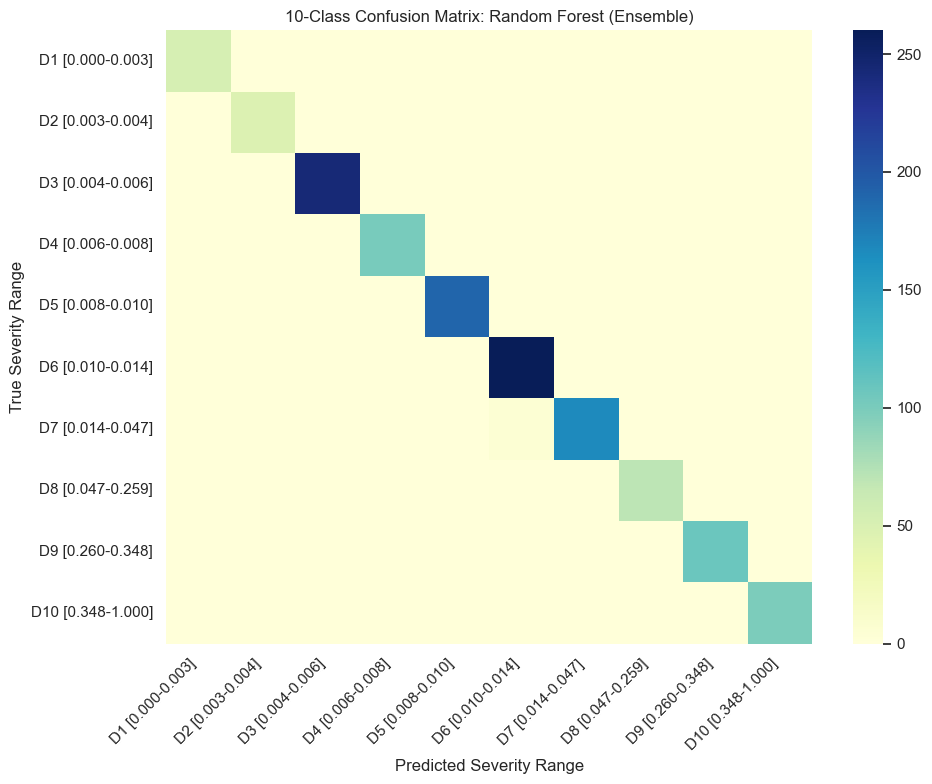

Exact class matches: 1337 / 1344


,datetime,gt_class_id,pred_class_id,gt_range,pred_range,match
0,2005-11-17 05:35:00,7,7,D8 [0.047-0.259],D8 [0.047-0.259],True
1,2005-11-17 05:40:00,9,9,D10 [0.348-1.000],D10 [0.348-1.000],True
2,2005-11-17 05:50:00,9,9,D10 [0.348-1.000],D10 [0.348-1.000],True
3,2005-11-17 05:55:00,8,8,D9 [0.260-0.348],D9 [0.260-0.348],True
4,2005-11-17 06:10:00,7,7,D8 [0.047-0.259],D8 [0.047-0.259],True
5,2005-11-17 06:15:00,7,7,D8 [0.047-0.259],D8 [0.047-0.259],True
6,2005-11-17 06:20:00,3,3,D4 [0.006-0.008],D4 [0.006-0.008],True
7,2005-11-17 06:45:00,9,9,D10 [0.348-1.000],D10 [0.348-1.000],True
8,2005-11-17 08:00:00,5,5,D6 [0.010-0.014],D6 [0.010-0.014],True
9,2005-11-17 08:05:00,6,6,D7 [0.014-0.047],D7 [0.014-0.047],True


In [70]:
# Compare one method from each allowed family (each used once)
model_candidates = {
    'Logistic Regression (GLM)': {
        'option': '(a)',
        'candidates': [
            make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.5, class_weight='balanced', random_state=42)),
            make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=1.0, class_weight='balanced', random_state=42)),
            make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=2.0, class_weight='balanced', random_state=42)),
        ],
    },
    'Support Vector Classifier (Robust Inference)': {
        'option': '(c)',
        'candidates': [
            make_pipeline(StandardScaler(), SVC(kernel='rbf', C=2.0, gamma='scale', class_weight='balanced', random_state=42)),
            make_pipeline(StandardScaler(), SVC(kernel='rbf', C=5.0, gamma='scale', class_weight='balanced', random_state=42)),
            make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced', random_state=42)),
        ],
    },
    'MLP Neural Network': {
        'option': '(d)',
        'candidates': [
            make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=800, random_state=42)),
            make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=900, random_state=42)),
            make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(96, 48), activation='relu', max_iter=900, random_state=42)),
        ],
    },
    'Random Forest (Ensemble)': {
        'option': '(f)',
        'candidates': [
            RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=1, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
            RandomForestClassifier(n_estimators=700, max_depth=None, min_samples_leaf=1, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
            RandomForestClassifier(n_estimators=700, max_depth=20, min_samples_leaf=1, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
        ],
    },
}

# Validation split for tuning candidate hyperparameters
val_size = max(50, int(len(X_train_multi) * 0.2))
X_fit, X_val = X_train_multi.iloc[:-val_size], X_train_multi.iloc[-val_size:]
y_fit, y_val = y_train_multi.iloc[:-val_size], y_train_multi.iloc[-val_size:]

multi_results = []
multi_predictions = {}

for model_name, info in model_candidates.items():
    best_local_model = None
    best_local_val_acc = -1.0

    for candidate_model in info['candidates']:
        candidate_model.fit(X_fit, y_fit)
        val_pred = candidate_model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        if val_acc > best_local_val_acc:
            best_local_val_acc = val_acc
            best_local_model = candidate_model

    best_local_model.fit(X_train_multi, y_train_multi)
    y_pred_multi = best_local_model.predict(X_test_multi)
    multi_predictions[model_name] = y_pred_multi

    multi_results.append({
        'method_option': info['option'],
        'model': model_name,
        'val_accuracy': best_local_val_acc,
        'accuracy': accuracy_score(y_test_multi, y_pred_multi),
        'precision_macro': precision_score(y_test_multi, y_pred_multi, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test_multi, y_pred_multi, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test_multi, y_pred_multi, average='macro', zero_division=0),
    })

multi_results_df = (
    pd.DataFrame(multi_results)
    .sort_values(['accuracy', 'f1_macro'], ascending=False)
    .reset_index(drop=True)
)

meets_multiclass_85 = bool((multi_results_df['accuracy'] >= 0.85).any())
print('Quantile multiclass 85% target met:', meets_multiclass_85)
display(multi_results_df)

best_multi_model_name = multi_results_df.iloc[0]['model']
best_multi_pred = multi_predictions[best_multi_model_name]
print('Best multiclass model:', best_multi_model_name)

class_labels = sorted(
    set(y_train_multi.unique().tolist())
    | set(y_test_multi.unique().tolist())
    | set(best_multi_pred.tolist())
)
cm_multi = confusion_matrix(y_test_multi, best_multi_pred, labels=class_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_multi,
    annot=False,
    cmap='YlGnBu',
    xticklabels=[id_to_label.get(i, str(i)) for i in class_labels],
    yticklabels=[id_to_label.get(i, str(i)) for i in class_labels],
)
plt.title(f'10-Class Confusion Matrix: {best_multi_model_name}')
plt.xlabel('Predicted Severity Range')
plt.ylabel('True Severity Range')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

multi_comparison_df = pd.DataFrame({
    'datetime': multi_df.iloc[split_idx_multi:]['datetime'].to_numpy(),
    'gt_class_id': y_test_multi.to_numpy(),
    'pred_class_id': best_multi_pred,
})
multi_comparison_df['gt_range'] = multi_comparison_df['gt_class_id'].map(id_to_label)
multi_comparison_df['pred_range'] = multi_comparison_df['pred_class_id'].map(id_to_label)
multi_comparison_df['match'] = multi_comparison_df['gt_class_id'] == multi_comparison_df['pred_class_id']

print('Exact class matches:', int(multi_comparison_df['match'].sum()), '/', len(multi_comparison_df))
display(multi_comparison_df.head(25))

In [71]:
# Feasibility check for next-window quantile prediction
naive_prev_class = multi_df.iloc[split_idx_multi:]['prev_severity_class'].astype(int).to_numpy()
naive_majority = np.full_like(y_test_multi.to_numpy(), fill_value=int(y_train_multi.mode().iloc[0]))

acc_prev = accuracy_score(y_test_multi, naive_prev_class)
acc_majority = accuracy_score(y_test_multi, naive_majority)

print('Naive baseline accuracy (predict previous class):', round(acc_prev, 4))
print('Naive baseline accuracy (predict train majority class):', round(acc_majority, 4))

Naive baseline accuracy (predict previous class): 0.3519
Naive baseline accuracy (predict train majority class): 0.0387
